# Laboratorio 8

In [1]:
from IPython.display import HTML, display, Markdown
HTML('''
<style>
div.input, div.jp-InputArea, div.prompt, .jp-Cell-inputWrapper {
    display: none !important;
}
.jp-OutputArea, div.output_area {
    display: block !important;
}
table {
    margin-left: auto;
    margin-right: auto;
}
h1, h2, h3 {
    page-break-after: avoid;
}
</style>
''')

## Inciso 1

In [2]:
import sys
import subprocess
import importlib.util
import inspect
import warnings
import time
from pathlib import Path

paquetes = ["pyreadr"]

for paquete in paquetes:
    if importlib.util.find_spec(paquete) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])

import pyreadr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.compose import TransformedTargetRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)

SEED = 42
N_TRAIN_CLF = 5000
N_TEST_CLF = 2000
N_TRAIN_REG = 3000
N_TEST_REG = 1500

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
def limpiar_precio(serie):
    if pd.api.types.is_numeric_dtype(serie):
        return pd.to_numeric(serie, errors="coerce")
    return pd.to_numeric(
        serie.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .replace({"nan": np.nan, "None": np.nan, "": np.nan}),
        errors="coerce"
    )

def cargar_rdata():
    data_dir = Path("data")
    rutas = []
    rutas += sorted(data_dir.glob("*.RData")) + sorted(data_dir.glob("*.rda"))
    rutas += sorted(data_dir.glob("**/*.RData")) + sorted(data_dir.glob("**/*.rda"))
    rutas += sorted(Path(".").glob("*.RData")) + sorted(Path(".").glob("*.rda"))

    rutas = list(dict.fromkeys(rutas))

    if not rutas:
        raise FileNotFoundError("No se encontró ningún archivo .RData en data/ ni en la carpeta actual.")

    rdata_path = rutas[0]
    rdata = pyreadr.read_r(str(rdata_path))

    tablas = [valor for valor in rdata.values() if isinstance(valor, pd.DataFrame)]

    if not tablas:
        raise ValueError("El archivo .RData no contiene una tabla compatible con pandas.")

    datos = tablas[0].copy()
    datos.columns = [str(col).strip() for col in datos.columns]
    return datos, rdata_path

df_original, rdata_path = cargar_rdata()

df_original.shape

(171748, 80)

In [4]:
def preparar_base(datos):
    datos = datos.copy()
    datos.columns = [str(col).strip() for col in datos.columns]

    candidatos_precio = [
        "price", "precio", "Price", "PRICE", "price_usd", "precio_usd",
        "adjusted_price", "listing_price"
    ]

    precio_col = next((col for col in candidatos_precio if col in datos.columns), None)

    if precio_col is None:
        columnas_precio = [
            col for col in datos.columns 
            if "price" in col.lower() or "precio" in col.lower()
        ]
        if not columnas_precio:
            raise ValueError("No se encontró una columna de precio.")
        precio_col = columnas_precio[0]

    datos[precio_col] = limpiar_precio(datos[precio_col])
    datos = datos.dropna(subset=[precio_col])
    datos = datos[datos[precio_col] > 0].copy()

    categoria_col = "categoria_precio"

    if categoria_col not in datos.columns:
        datos[categoria_col] = pd.qcut(
            datos[precio_col],
            q=3,
            labels=["barata", "media", "cara"],
            duplicates="drop"
        )

    datos[categoria_col] = datos[categoria_col].astype("category")

    return datos, precio_col, categoria_col

df, precio_col, categoria_col = preparar_base(df_original)

resumen_base = pd.DataFrame({
    "filas": [df.shape[0]],
    "columnas": [df.shape[1]],
    "precio": [precio_col],
    "respuesta": [categoria_col],
    "archivo": [str(rdata_path)]
})

display(Markdown("**Tabla 1. Resumen general del conjunto de datos**"))
display(resumen_base)

**Tabla 1. Resumen general del conjunto de datos**

,filas,columnas,precio,respuesta,archivo
0,76246,81,price,categoria_precio,data\listings.RData


In [5]:
def leer_tabla(path):
    sufijo = path.suffix.lower()
    if sufijo == ".csv":
        return pd.read_csv(path)
    if sufijo in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    if sufijo == ".parquet":
        return pd.read_parquet(path)
    if sufijo in [".pkl", ".pickle"]:
        return pd.read_pickle(path)
    raise ValueError(path)

data_dir = Path("data")
extensiones = ["*.csv", "*.xlsx", "*.xls", "*.parquet", "*.pkl", "*.pickle"]

archivos_tabla = []
for extension in extensiones:
    archivos_tabla.extend(sorted(data_dir.glob(extension)))
    archivos_tabla.extend(sorted(data_dir.glob(f"**/{extension}")))

train_files = [
    path for path in archivos_tabla
    if any(txt in path.stem.lower() for txt in ["train", "entrenamiento", "training"])
]

test_files = [
    path for path in archivos_tabla
    if any(txt in path.stem.lower() for txt in ["test", "prueba", "testing"])
]

if train_files and test_files:
    train_df, _, _ = preparar_base(leer_tabla(train_files[0]))
    test_df, _, _ = preparar_base(leer_tabla(test_files[0]))
    origen_split = "archivos"
else:
    train_df, test_df = train_test_split(
        df,
        test_size=0.30,
        random_state=SEED,
        stratify=df[categoria_col]
    )
    origen_split = "semilla"

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

resumen_split = pd.DataFrame({
    "conjunto": ["train", "test"],
    "filas": [train_df.shape[0], test_df.shape[0]],
    "columnas": [train_df.shape[1], test_df.shape[1]],
    "origen del split": [origen_split, origen_split]
})

display(Markdown("**Tabla 2. División del conjunto de datos**"))
display(resumen_split)

**Tabla 2. División del conjunto de datos**

,conjunto,filas,columnas,origen del split
0,train,53372,81,semilla
1,test,22874,81,semilla


In [6]:
dist_respuesta = pd.concat([
    train_df[categoria_col].value_counts().sort_index().rename("train"),
    test_df[categoria_col].value_counts().sort_index().rename("test")
], axis=1).reset_index().rename(columns={"index": "categoría"})

display(Markdown("**Tabla 3. Distribución de la variable respuesta**"))
display(dist_respuesta)

**Tabla 3. Distribución de la variable respuesta**

,categoria_precio,train,test
0,barata,17982,7707
1,media,17607,7546
2,cara,17783,7621


## Inciso 2

In [7]:
tipos_variables = (
    pd.DataFrame(df.dtypes.astype(str).value_counts())
    .reset_index()
    .rename(columns={"index": "tipo", "count": "cantidad", 0: "cantidad"})
)

display(Markdown("**Tabla 4. Tipos de variables en la base**"))
display(tipos_variables)

**Tabla 4. Tipos de variables en la base**

,tipo,cantidad
0,object,46
1,int32,18
2,float64,16
3,category,1


In [8]:
faltantes = pd.DataFrame({
    "columna": df.columns,
    "faltantes": df.isna().sum().values,
    "porcentaje": (df.isna().mean().values * 100).round(2),
    "tipo": df.dtypes.astype(str).values,
    "unicos": df.nunique(dropna=True).values
}).sort_values(["porcentaje", "faltantes"], ascending=False)

display(Markdown("**Tabla 5. Variables con mayor cantidad de valores faltantes**"))
display(faltantes.head(15))

**Tabla 5. Variables con mayor cantidad de valores faltantes**

,columna,faltantes,porcentaje,tipo,unicos
49,calendar_updated,76246,100.00,object,0
29,neighbourhood_group_cleansed,38121,50.00,object,9
66,review_scores_accuracy,13417,17.60,float64,158
67,review_scores_cleanliness,13417,17.60,float64,171
68,review_scores_checkin,13417,17.60,float64,143
69,review_scores_communication,13417,17.60,float64,146
70,review_scores_location,13417,17.60,float64,170
71,review_scores_value,13417,17.60,float64,172
65,review_scores_rating,13413,17.59,float64,161
78,reviews_per_month,13413,17.59,float64,1050


In [9]:
resumen_precio = df[precio_col].describe().to_frame().T.round(2)

display(Markdown("**Tabla 6. Resumen del precio**"))
display(resumen_precio)

**Tabla 6. Resumen del precio**

,count,mean,std,min,25%,50%,75%,max
price,76246.0,750.51,4250.61,8.0,120.0,193.0,326.0,50123.0


In [10]:
precio_categoria = (
    df.groupby(categoria_col)[precio_col]
    .agg(["count", "min", "median", "mean", "max"])
    .round(2)
    .reset_index()
    .rename(columns={categoria_col: "categoría"})
)

display(Markdown("**Tabla 7. Precio por categoría**"))
display(precio_categoria)

**Tabla 7. Precio por categoría**

,categoría,count,min,median,mean,max
0,barata,25689,8.0,99.0,95.80,143.0
1,media,25153,144.0,194.0,197.49,268.0
2,cara,25404,269.0,437.0,1960.12,50123.0


In [11]:
def convertir_columnas(datos):
    datos = datos.copy()

    for col in list(datos.columns):
        if datos[col].dtype == "object":
            valores = datos[col].astype(str).str.lower().str.strip()
            mask = datos[col].notna()
            bool_validos = valores[mask].isin(["t", "f", "true", "false", "yes", "no", "si", "sí", "1", "0"])
            if len(bool_validos) > 0 and bool_validos.mean() >= 0.90:
                datos[col] = valores.map({
                    "t": 1, "true": 1, "yes": 1, "si": 1, "sí": 1, "1": 1,
                    "f": 0, "false": 0, "no": 0, "0": 0
                })

        if datos[col].dtype == "object":
            valores = (
                datos[col].astype(str)
                .str.replace("$", "", regex=False)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
                .str.strip()
            )
            convertidos = pd.to_numeric(valores, errors="coerce")
            mask = datos[col].notna()
            if mask.sum() > 0 and convertidos[mask].notna().mean() >= 0.90:
                datos[col] = convertidos

    return datos

def detectar_fechas(datos):
    nombres_fecha = {
        "last_scraped",
        "host_since",
        "first_review",
        "last_review",
        "calendar_last_scraped"
    }

    columnas_fecha = []

    for col in datos.columns:
        col_lower = col.lower()
        if col_lower in nombres_fecha or col_lower.endswith("_date"):
            if col_lower not in {"accommodates"}:
                columnas_fecha.append(col)

    return columnas_fecha

def transformar_fechas(datos, columnas_fecha):
    datos = datos.copy()
    referencia = pd.Timestamp("2026-01-01")

    for col in columnas_fecha:
        fechas = pd.to_datetime(datos[col], errors="coerce", utc=True).dt.tz_localize(None)
        datos[col + "_dias"] = (referencia - fechas).dt.days

    return datos

def preparar_features_para_modelo(train_df, test_df, precio_col, categoria_col, incluir_precio=False):
    train_base = train_df.copy()
    test_base = test_df.copy()

    train_base = convertir_columnas(train_base)
    test_base = convertir_columnas(test_base)

    columnas_fecha = detectar_fechas(train_base)
    train_base = transformar_fechas(train_base, columnas_fecha)
    test_base = transformar_fechas(test_base, columnas_fecha)

    columnas = train_base.columns.tolist()

    columnas_url = [
        col for col in columnas
        if any(txt in col.lower() for txt in ["url", "picture", "thumbnail"])
    ]

    columnas_id = [
        col for col in columnas
        if col.lower() == "id" or col.lower().endswith("_id") or col.lower() in ["scrape_id", "host_id"]
    ]

    columnas_texto = [
        col for col in columnas
        if any(txt in col.lower() for txt in ["description", "overview", "about", "amenities", "license", "name"])
    ]

    columnas_fuga = [
        col for col in columnas
        if any(txt in col.lower() for txt in ["revenue", "income"])
    ]

    columnas_sin_info = [
        col for col in columnas
        if train_base[col].isna().mean() >= 0.90 or train_base[col].nunique(dropna=True) <= 1
    ]

    columnas_respuesta = [categoria_col]
    if not incluir_precio:
        columnas_respuesta.append(precio_col)

    columnas_eliminar = set(
        columnas_respuesta
        + columnas_fecha
        + columnas_url
        + columnas_id
        + columnas_texto
        + columnas_fuga
        + columnas_sin_info
    )

    columnas_candidatas = [col for col in train_base.columns if col not in columnas_eliminar]

    columnas_alta_cardinalidad = [
        col for col in columnas_candidatas
        if str(train_base[col].dtype) in ["object", "category"] and train_base[col].nunique(dropna=True) > 80
    ]

    columnas_eliminar.update(columnas_alta_cardinalidad)

    X_train = train_base.drop(columns=list(columnas_eliminar), errors="ignore")
    X_test = test_base.drop(columns=list(columnas_eliminar), errors="ignore")

    num_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
    cat_cols = [col for col in X_train.columns if col not in num_cols]

    params = inspect.signature(OneHotEncoder).parameters
    kwargs = {"handle_unknown": "ignore"}

    if "sparse_output" in params:
        kwargs["sparse_output"] = False
    else:
        kwargs["sparse"] = False

    if "max_categories" in params:
        kwargs["max_categories"] = 30

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(**kwargs))
            ]), cat_cols)
        ],
        sparse_threshold=0
    )

    resumen = {
        "columnas_fecha": columnas_fecha,
        "columnas_eliminar": sorted(columnas_eliminar),
        "columnas_alta_cardinalidad": columnas_alta_cardinalidad,
        "num_cols": num_cols,
        "cat_cols": cat_cols
    }

    return X_train, X_test, preprocessor, resumen

X_train_clf, X_test_clf, preprocessor_clf, resumen_preparacion = preparar_features_para_modelo(
    train_df,
    test_df,
    precio_col,
    categoria_col,
    incluir_precio=False
)

y_train_clf = train_df[categoria_col].astype(str)
y_test_clf = test_df[categoria_col].astype(str)

preprocessor_tmp = clone(preprocessor_clf)
X_train_tmp = preprocessor_tmp.fit_transform(X_train_clf)
X_test_tmp = preprocessor_tmp.transform(X_test_clf)

resumen_transformaciones = pd.DataFrame({
    "parte": [
        "respuesta",
        "precio",
        "split",
        "faltantes numéricos",
        "faltantes categóricos",
        "variables numéricas",
        "variables categóricas",
        "fechas transformadas",
        "columnas eliminadas",
        "matriz train",
        "matriz test"
    ],
    "resultado": [
        categoria_col,
        precio_col,
        origen_split,
        "mediana",
        "moda",
        "escaladas",
        "one hot encoding",
        len(resumen_preparacion["columnas_fecha"]),
        len(resumen_preparacion["columnas_eliminar"]),
        f"{X_train_tmp.shape[0]:,} x {X_train_tmp.shape[1]:,}",
        f"{X_test_tmp.shape[0]:,} x {X_test_tmp.shape[1]:,}"
    ]
})

display(Markdown("**Tabla 8. Resumen de transformaciones aplicadas**"))
display(resumen_transformaciones)

**Tabla 8. Resumen de transformaciones aplicadas**

,parte,resultado
0,respuesta,categoria_precio
1,precio,price
2,split,semilla
3,faltantes numéricos,mediana
4,faltantes categóricos,moda
5,variables numéricas,escaladas
6,variables categóricas,one hot encoding
7,fechas transformadas,5
8,columnas eliminadas,30
9,matriz train,"53,372 x 116"


## Inciso 3

In [12]:
display(Markdown("**Tabla 9. Variable respuesta utilizada en los modelos de clasificación**"))
display(
    pd.DataFrame({
        "variable": [categoria_col],
        "tipo": [str(train_df[categoria_col].dtype)],
        "categorías": [", ".join(sorted(y_train_clf.unique()))]
    })
)

**Tabla 9. Variable respuesta utilizada en los modelos de clasificación**

,variable,tipo,categorías
0,categoria_precio,category,"barata, cara, media"


## Inciso 4

In [13]:
def muestra_clasificacion(X, y, n, seed):
    if len(y) <= n:
        return X.copy(), y.copy()
    X_s, _, y_s, _ = train_test_split(
        X,
        y,
        train_size=n,
        random_state=seed,
        stratify=y
    )
    return X_s.copy(), y_s.copy()

X_train_clf_s, y_train_clf_s = muestra_clasificacion(X_train_clf, y_train_clf, N_TRAIN_CLF, SEED)
X_test_clf_s, y_test_clf_s = muestra_clasificacion(X_test_clf, y_test_clf, N_TEST_CLF, SEED)

muestras_clasificacion = pd.DataFrame({
    "conjunto": ["train", "test"],
    "filas usadas": [X_train_clf_s.shape[0], X_test_clf_s.shape[0]],
    "columnas antes de codificar": [X_train_clf_s.shape[1], X_test_clf_s.shape[1]]
})

display(Markdown("**Tabla 10. Muestras utilizadas para clasificación**"))
display(muestras_clasificacion)

**Tabla 10. Muestras utilizadas para clasificación**

,conjunto,filas usadas,columnas antes de codificar
0,train,5000,56
1,test,2000,56


In [14]:
def evaluar_clasificador(nombre, algoritmo, modelo, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ("preprocessor", clone(preprocessor_clf)),
        ("model", clone(modelo))
    ])

    inicio = time.time()
    pipe.fit(X_train, y_train)
    tiempo = time.time() - inicio

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)

    return {
        "algoritmo": algoritmo,
        "modelo": nombre,
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "precision_test": precision_score(y_test, pred_test, average="weighted", zero_division=0),
        "recall_test": recall_score(y_test, pred_test, average="weighted", zero_division=0),
        "f1_test": f1_score(y_test, pred_test, average="weighted", zero_division=0),
        "errores_test": int((pred_test != y_test).sum()),
        "tiempo_seg": tiempo,
        "pipeline": pipe,
        "pred_test": pred_test,
        "pred_train": pred_train
    }

modelos_svm = [
    ("SVM lineal C=0.1", "SVM", SVC(kernel="linear", C=0.1)),
    ("SVM lineal C=1", "SVM", SVC(kernel="linear", C=1)),
    ("SVM RBF C=1 gamma=scale", "SVM", SVC(kernel="rbf", C=1, gamma="scale")),
    ("SVM RBF C=10 gamma=scale", "SVM", SVC(kernel="rbf", C=10, gamma="scale")),
    ("SVM RBF C=1 gamma=0.01", "SVM", SVC(kernel="rbf", C=1, gamma=0.01)),
    ("SVM polinomial C=1 d=2", "SVM", SVC(kernel="poly", C=1, degree=2, gamma="scale")),
    ("SVM polinomial C=1 d=3", "SVM", SVC(kernel="poly", C=1, degree=3, gamma="scale"))
]

resultados_svm_detalle = [
    evaluar_clasificador(nombre, algoritmo, modelo, X_train_clf_s, y_train_clf_s, X_test_clf_s, y_test_clf_s)
    for nombre, algoritmo, modelo in modelos_svm
]

resultados_svm = (
    pd.DataFrame(resultados_svm_detalle)
    .drop(columns=["pipeline", "pred_test", "pred_train"])
    .sort_values("f1_test", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("**Tabla 11. Resultados de los modelos SVM evaluados**"))
display(resultados_svm.round(4))

**Tabla 11. Resultados de los modelos SVM evaluados**

,algoritmo,modelo,accuracy_train,accuracy_test,precision_test,recall_test,f1_test,errores_test,tiempo_seg
0,SVM,SVM RBF C=1 gamma=scale,0.771,0.698,0.697,0.698,0.697,605,1.523
1,SVM,SVM RBF C=10 gamma=scale,0.900,0.698,0.696,0.698,0.696,604,1.978
2,SVM,SVM polinomial C=1 d=2,0.742,0.691,0.696,0.691,0.693,619,4.258
3,SVM,SVM RBF C=1 gamma=0.01,0.732,0.690,0.688,0.690,0.688,621,1.509
4,SVM,SVM polinomial C=1 d=3,0.758,0.679,0.698,0.679,0.683,642,4.829
5,SVM,SVM lineal C=1,0.690,0.678,0.674,0.678,0.675,643,3.304
6,SVM,SVM lineal C=0.1,0.686,0.676,0.671,0.676,0.672,647,1.344


In [15]:
best_svm_info = max(resultados_svm_detalle, key=lambda x: x["f1_test"])

display(Markdown(
    f"El mejor modelo SVM según F1-score ponderado fue **{best_svm_info['modelo']}**, "
    f"con un accuracy de prueba de **{best_svm_info['accuracy_test']:.4f}** y un F1-score de **{best_svm_info['f1_test']:.4f}**."
))

El mejor modelo SVM según F1-score ponderado fue **SVM RBF C=1 gamma=scale**, con un accuracy de prueba de **0.6975** y un F1-score de **0.6969**.

## Inciso 5

In [16]:
predicciones_ejemplo = pd.DataFrame({
    "valor real": y_test_clf_s.iloc[:10].values,
    "predicción": best_svm_info["pred_test"][:10]
})

display(Markdown("**Tabla 12. Ejemplo de predicciones del mejor modelo SVM**"))
display(predicciones_ejemplo)

**Tabla 12. Ejemplo de predicciones del mejor modelo SVM**

,valor real,predicción
0,cara,cara
1,barata,media
2,media,barata
3,media,media
4,cara,cara
5,cara,cara
6,media,media
7,barata,barata
8,media,media
9,cara,cara


## Inciso 6

**Gráfico 1. Matriz de confusión - SVM lineal C=1**

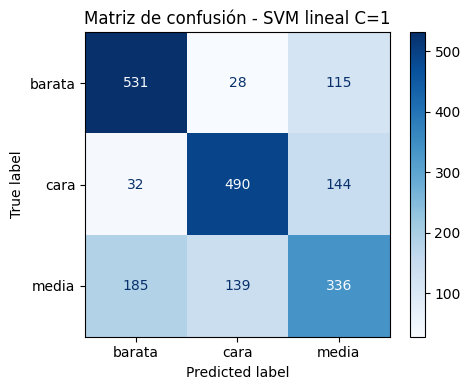

**Tabla. Reporte de clasificación - SVM lineal C=1**

,precision,recall,f1-score,support
barata,0.710,0.788,0.747,674.000
cara,0.746,0.736,0.741,666.000
media,0.565,0.509,0.535,660.000
accuracy,0.678,0.678,0.678,0.678
macro avg,0.673,0.678,0.674,2000.000
weighted avg,0.674,0.678,0.675,2000.000


**Gráfico 2. Matriz de confusión - SVM RBF C=1 gamma=scale**

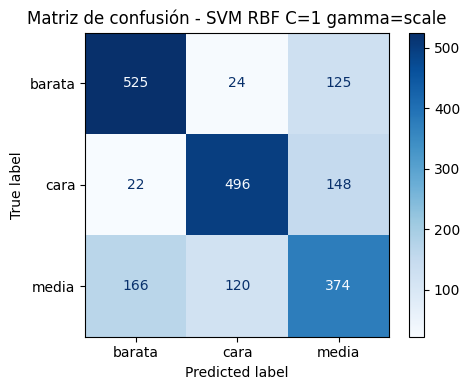

**Tabla. Reporte de clasificación - SVM RBF C=1 gamma=scale**

,precision,recall,f1-score,support
barata,0.736,0.779,0.757,674.000
cara,0.775,0.745,0.760,666.000
media,0.578,0.567,0.572,660.000
accuracy,0.698,0.698,0.698,0.698
macro avg,0.696,0.697,0.696,2000.000
weighted avg,0.697,0.698,0.697,2000.000


**Gráfico 3. Matriz de confusión - SVM polinomial C=1 d=2**

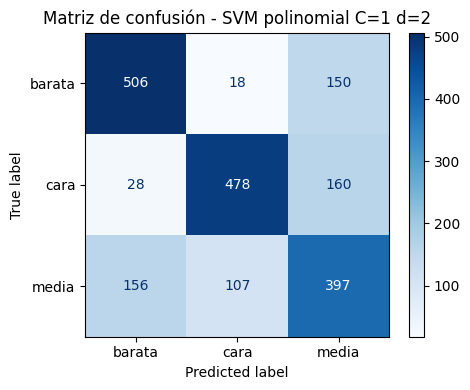

**Tabla. Reporte de clasificación - SVM polinomial C=1 d=2**

,precision,recall,f1-score,support
barata,0.733,0.751,0.742,674.00
cara,0.793,0.718,0.753,666.00
media,0.562,0.602,0.581,660.00
accuracy,0.690,0.690,0.690,0.69
macro avg,0.696,0.690,0.692,2000.00
weighted avg,0.696,0.690,0.693,2000.00


In [17]:
def mejor_por_kernel(detalles, texto):
    candidatos = [r for r in detalles if texto in r["modelo"]]
    return max(candidatos, key=lambda x: x["f1_test"])

svm_principales = [
    mejor_por_kernel(resultados_svm_detalle, "lineal"),
    mejor_por_kernel(resultados_svm_detalle, "RBF"),
    mejor_por_kernel(resultados_svm_detalle, "polinomial")
]

for i, info in enumerate(svm_principales, start=1):
    nombre_archivo = f"grafico{i}.png"
    ruta_grafico = OUTPUT_DIR / nombre_archivo

    display(Markdown(f"**Gráfico {i}. Matriz de confusión - {info['modelo']}**"))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test_clf_s,
        info["pred_test"],
        labels=sorted(y_train_clf_s.unique()),
        cmap="Blues",
        ax=ax,
        colorbar=True
    )
    ax.set_title(f"Matriz de confusión - {info['modelo']}")
    plt.tight_layout()
    fig.savefig(ruta_grafico, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    reporte = pd.DataFrame(
        classification_report(
            y_test_clf_s,
            info["pred_test"],
            output_dict=True,
            zero_division=0
        )
    ).T.round(3)

    display(Markdown(f"**Tabla. Reporte de clasificación - {info['modelo']}**"))
    display(reporte)


## Inciso 7

In [18]:
sobreajuste_svm = resultados_svm.copy()
sobreajuste_svm["diferencia_train_test"] = (
    sobreajuste_svm["accuracy_train"] - sobreajuste_svm["accuracy_test"]
)

sobreajuste_svm["diagnóstico"] = np.where(
    sobreajuste_svm["diferencia_train_test"] > 0.15,
    "posible sobreajuste",
    np.where(
        sobreajuste_svm["accuracy_test"] < 0.55,
        "posible desajuste",
        "ajuste aceptable"
    )
)

display(Markdown("**Tabla 14. Análisis de sobreajuste en modelos SVM**"))
display(
    sobreajuste_svm[
        ["modelo", "accuracy_train", "accuracy_test", "diferencia_train_test", "diagnóstico"]
    ].round(4)
)

**Tabla 14. Análisis de sobreajuste en modelos SVM**

,modelo,accuracy_train,accuracy_test,diferencia_train_test,diagnóstico
0,SVM RBF C=1 gamma=scale,0.771,0.698,0.074,ajuste aceptable
1,SVM RBF C=10 gamma=scale,0.900,0.698,0.202,posible sobreajuste
2,SVM polinomial C=1 d=2,0.742,0.691,0.052,ajuste aceptable
3,SVM RBF C=1 gamma=0.01,0.732,0.690,0.043,ajuste aceptable
4,SVM polinomial C=1 d=3,0.758,0.679,0.079,ajuste aceptable
5,SVM lineal C=1,0.690,0.678,0.011,ajuste aceptable
6,SVM lineal C=0.1,0.686,0.676,0.009,ajuste aceptable


In [19]:
display(Markdown(
    "Para manejar el sobreajuste se pueden probar valores más bajos de `C`, reducir la complejidad del kernel, "
    "usar validación cruzada, aumentar la cantidad de datos de entrenamiento o seleccionar variables más relevantes. "
    "Si el problema fuera desajuste, convendría probar kernels más flexibles, ajustar hiperparámetros o agregar variables con más información."
))

Para manejar el sobreajuste se pueden probar valores más bajos de `C`, reducir la complejidad del kernel, usar validación cruzada, aumentar la cantidad de datos de entrenamiento o seleccionar variables más relevantes. Si el problema fuera desajuste, convendría probar kernels más flexibles, ajustar hiperparámetros o agregar variables con más información.

## Inciso 8

In [20]:
def resumen_errores(y_true, y_pred):
    labels = sorted(pd.Series(y_true).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    filas = []

    for i, real in enumerate(labels):
        for j, pred in enumerate(labels):
            if i != j and cm[i, j] > 0:
                filas.append({
                    "real": real,
                    "predicho": pred,
                    "cantidad": int(cm[i, j])
                })

    return pd.DataFrame(filas).sort_values("cantidad", ascending=False).reset_index(drop=True)

errores_best_svm = resumen_errores(y_test_clf_s, best_svm_info["pred_test"])

display(Markdown("**Tabla 13. Principales confusiones del mejor modelo SVM**"))
display(errores_best_svm.head(10))

**Tabla 13. Principales confusiones del mejor modelo SVM**

,real,predicho,cantidad
0,media,barata,166
1,cara,media,148
2,barata,media,125
3,media,cara,120
4,barata,cara,24
5,cara,barata,22


In [21]:
peor_confusion = errores_best_svm.iloc[0]

display(Markdown(
    f"El error más frecuente del mejor modelo SVM fue clasificar propiedades reales de categoría "
    f"**{peor_confusion['real']}** como **{peor_confusion['predicho']}**, con **{int(peor_confusion['cantidad'])}** casos. "
    "Este tipo de error es importante porque puede afectar la recomendación de propiedades: una casa de precio medio "
    "podría ser ofrecida como si perteneciera a un segmento diferente."
))

El error más frecuente del mejor modelo SVM fue clasificar propiedades reales de categoría **media** como **barata**, con **166** casos. Este tipo de error es importante porque puede afectar la recomendación de propiedades: una casa de precio medio podría ser ofrecida como si perteneciera a un segmento diferente.

## Inciso 9

In [22]:
otros_modelos_clf = [
    ("Árbol de decisión max_depth=5", "Árbol de decisión", DecisionTreeClassifier(max_depth=5, random_state=SEED)),
    ("Árbol de decisión max_depth=10", "Árbol de decisión", DecisionTreeClassifier(max_depth=10, random_state=SEED)),
    ("Random Forest 80 árboles", "Random Forest", RandomForestClassifier(n_estimators=80, random_state=SEED, n_jobs=-1)),
    ("Random Forest max_depth=12", "Random Forest", RandomForestClassifier(n_estimators=80, max_depth=12, random_state=SEED, n_jobs=-1)),
    ("Naive Bayes Gaussiano", "Naive Bayes", GaussianNB()),
    ("KNN k=5", "KNN", KNeighborsClassifier(n_neighbors=5)),
    ("KNN k=11", "KNN", KNeighborsClassifier(n_neighbors=11)),
    ("Regresión logística C=1", "Regresión logística", LogisticRegression(max_iter=1000, C=1, n_jobs=-1)),
    ("Regresión logística C=0.5", "Regresión logística", LogisticRegression(max_iter=1000, C=0.5, n_jobs=-1))
]

resultados_clf_detalle = []

for nombre, algoritmo, modelo in otros_modelos_clf:
    resultados_clf_detalle.append(
        evaluar_clasificador(nombre, algoritmo, modelo, X_train_clf_s, y_train_clf_s, X_test_clf_s, y_test_clf_s)
    )

resultados_clf_detalle.append(best_svm_info)

resultados_clf = (
    pd.DataFrame(resultados_clf_detalle)
    .drop(columns=["pipeline", "pred_test", "pred_train"])
    .sort_values(["algoritmo", "f1_test"], ascending=[True, False])
    .reset_index(drop=True)
)

mejor_por_algoritmo_clf = (
    resultados_clf
    .sort_values("f1_test", ascending=False)
    .groupby("algoritmo", as_index=False)
    .first()
    .sort_values("f1_test", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("**Tabla 15. Mejor modelo de clasificación por algoritmo**"))
display(mejor_por_algoritmo_clf.round(4))

**Tabla 15. Mejor modelo de clasificación por algoritmo**

,algoritmo,modelo,accuracy_train,accuracy_test,precision_test,recall_test,f1_test,errores_test,tiempo_seg
0,Random Forest,Random Forest 80 árboles,1.000,0.709,0.707,0.709,0.707,583,1.171
1,SVM,SVM RBF C=1 gamma=scale,0.771,0.698,0.697,0.698,0.697,605,1.523
2,Regresión logística,Regresión logística C=1,0.683,0.682,0.678,0.682,0.679,635,1.198
3,Árbol de decisión,Árbol de decisión max_depth=10,0.807,0.662,0.662,0.662,0.661,675,0.650
4,KNN,KNN k=11,0.704,0.627,0.626,0.627,0.624,745,0.350
5,Naive Bayes,Naive Bayes Gaussiano,0.524,0.505,0.591,0.505,0.470,989,0.317


In [23]:
mejor_clf_general = mejor_por_algoritmo_clf.iloc[0]

display(Markdown(
    f"El mejor modelo de clasificación fue **{mejor_clf_general['modelo']}**, "
    f"con un accuracy de prueba de **{mejor_clf_general['accuracy_test']:.4f}** y un F1-score ponderado de "
    f"**{mejor_clf_general['f1_test']:.4f}**. Para esta comparación, el F1-score ponderado es una métrica útil "
    "porque considera el desempeño de todas las clases."
))

El mejor modelo de clasificación fue **Random Forest 80 árboles**, con un accuracy de prueba de **0.7085** y un F1-score ponderado de **0.7070**. Para esta comparación, el F1-score ponderado es una métrica útil porque considera el desempeño de todas las clases.

## Inciso 10

In [24]:
comparacion_sobreajuste_clf = mejor_por_algoritmo_clf.copy()
comparacion_sobreajuste_clf["diferencia_train_test"] = (
    comparacion_sobreajuste_clf["accuracy_train"] - comparacion_sobreajuste_clf["accuracy_test"]
)

comparacion_sobreajuste_clf["diagnóstico"] = np.where(
    comparacion_sobreajuste_clf["diferencia_train_test"] > 0.15,
    "posible sobreajuste",
    np.where(
        comparacion_sobreajuste_clf["accuracy_test"] < 0.55,
        "posible desajuste",
        "ajuste aceptable"
    )
)

display(Markdown("**Tabla 16. Comparación del sobreajuste en clasificación**"))
display(
    comparacion_sobreajuste_clf[
        ["algoritmo", "modelo", "accuracy_train", "accuracy_test", "diferencia_train_test", "diagnóstico", "tiempo_seg"]
    ].round(4)
)

**Tabla 16. Comparación del sobreajuste en clasificación**

,algoritmo,modelo,accuracy_train,accuracy_test,diferencia_train_test,diagnóstico,tiempo_seg
0,Random Forest,Random Forest 80 árboles,1.000,0.709,2.915e-01,posible sobreajuste,1.171
1,SVM,SVM RBF C=1 gamma=scale,0.771,0.698,7.390e-02,ajuste aceptable,1.523
2,Regresión logística,Regresión logística C=1,0.683,0.682,3.000e-04,ajuste aceptable,1.198
3,Árbol de decisión,Árbol de decisión max_depth=10,0.807,0.662,1.445e-01,ajuste aceptable,0.650
4,KNN,KNN k=11,0.704,0.627,7.630e-02,ajuste aceptable,0.350
5,Naive Bayes,Naive Bayes Gaussiano,0.524,0.505,1.890e-02,posible desajuste,0.317


In [25]:
mas_sobreajustado = comparacion_sobreajuste_clf.sort_values("diferencia_train_test", ascending=False).iloc[0]
mas_lento = comparacion_sobreajuste_clf.sort_values("tiempo_seg", ascending=False).iloc[0]

display(Markdown(
    f"El modelo con mayor diferencia entre entrenamiento y prueba fue **{mas_sobreajustado['modelo']}**, "
    f"por lo que es el que muestra mayor tendencia al sobreajuste dentro de esta comparación. "
    f"El modelo que tomó más tiempo de procesamiento fue **{mas_lento['modelo']}**."
))

El modelo con mayor diferencia entre entrenamiento y prueba fue **Random Forest 80 árboles**, por lo que es el que muestra mayor tendencia al sobreajuste dentro de esta comparación. El modelo que tomó más tiempo de procesamiento fue **SVM RBF C=1 gamma=scale**.

## Inciso 11

In [26]:
X_train_reg, X_test_reg, preprocessor_reg, resumen_preparacion_reg = preparar_features_para_modelo(
    train_df,
    test_df,
    precio_col,
    categoria_col,
    incluir_precio=False
)

y_train_reg = train_df[precio_col].astype(float)
y_test_reg = test_df[precio_col].astype(float)

def muestra_regresion(X, y, n, seed):
    if len(y) <= n:
        return X.copy(), y.copy()
    indices = y.sample(n=n, random_state=seed).index
    return X.loc[indices].copy(), y.loc[indices].copy()

X_train_reg_s, y_train_reg_s = muestra_regresion(X_train_reg, y_train_reg, N_TRAIN_REG, SEED)
X_test_reg_s, y_test_reg_s = muestra_regresion(X_test_reg, y_test_reg, N_TEST_REG, SEED)

muestras_regresion = pd.DataFrame({
    "conjunto": ["train", "test"],
    "filas usadas": [X_train_reg_s.shape[0], X_test_reg_s.shape[0]],
    "columnas antes de codificar": [X_train_reg_s.shape[1], X_test_reg_s.shape[1]]
})

display(Markdown("**Tabla 17. Muestras utilizadas para regresión**"))
display(muestras_regresion)

**Tabla 17. Muestras utilizadas para regresión**

,conjunto,filas usadas,columnas antes de codificar
0,train,3000,56
1,test,1500,56


In [27]:
def crear_regresor(modelo):
    pipe = Pipeline([
        ("preprocessor", clone(preprocessor_reg)),
        ("model", clone(modelo))
    ])
    return TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1
    )

def evaluar_regresor(nombre, algoritmo, modelo, X_train, y_train, X_test, y_test):
    reg = crear_regresor(modelo)

    inicio = time.time()
    reg.fit(X_train, y_train)
    tiempo = time.time() - inicio

    pred_train = np.maximum(reg.predict(X_train), 0)
    pred_test = np.maximum(reg.predict(X_test), 0)

    return {
        "algoritmo": algoritmo,
        "modelo": nombre,
        "mae_train": mean_absolute_error(y_train, pred_train),
        "mae_test": mean_absolute_error(y_test, pred_test),
        "rmse_train": float(np.sqrt(mean_squared_error(y_train, pred_train))),
        "rmse_test": float(np.sqrt(mean_squared_error(y_test, pred_test))),
        "r2_train": r2_score(y_train, pred_train),
        "r2_test": r2_score(y_test, pred_test),
        "tiempo_seg": tiempo,
        "regresor": reg,
        "pred_test": pred_test,
        "pred_train": pred_train
    }

modelos_svr = [
    ("SVR lineal C=1 epsilon=0.1", "SVR", SVR(kernel="linear", C=1, epsilon=0.1)),
    ("SVR RBF C=10 epsilon=0.1", "SVR", SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.1)),
    ("SVR RBF C=100 epsilon=0.2", "SVR", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.2)),
    ("SVR polinomial C=10 d=2", "SVR", SVR(kernel="poly", C=10, degree=2, gamma="scale", epsilon=0.2))
]

resultados_svr_detalle = [
    evaluar_regresor(nombre, algoritmo, modelo, X_train_reg_s, y_train_reg_s, X_test_reg_s, y_test_reg_s)
    for nombre, algoritmo, modelo in modelos_svr
]

resultados_svr = (
    pd.DataFrame(resultados_svr_detalle)
    .drop(columns=["regresor", "pred_test", "pred_train"])
    .sort_values("rmse_test")
    .reset_index(drop=True)
)

display(Markdown("**Tabla 18. Tuneo de modelos SVR**"))
display(resultados_svr.round(4))

**Tabla 18. Tuneo de modelos SVR**

,algoritmo,modelo,mae_train,mae_test,rmse_train,rmse_test,r2_train,r2_test,tiempo_seg
0,SVR,SVR RBF C=100 epsilon=0.2,118.271,300.987,697.255,2306.934,0.967,0.572,1.393
1,SVR,SVR RBF C=10 epsilon=0.1,186.369,324.458,2134.361,2716.349,0.686,0.406,2.774
2,SVR,SVR polinomial C=10 d=2,302.444,378.613,2686.493,2955.770,0.503,0.297,5.072
3,SVR,SVR lineal C=1 epsilon=0.1,462.099,418.350,3447.138,3300.018,0.181,0.124,16.396


In [28]:
best_svr_info = min(resultados_svr_detalle, key=lambda x: x["rmse_test"])

display(Markdown(
    f"El mejor modelo SVR fue **{best_svr_info['modelo']}**, con un RMSE de prueba de "
    f"**{best_svr_info['rmse_test']:.2f}** y un MAE de prueba de **{best_svr_info['mae_test']:.2f}**."
))

El mejor modelo SVR fue **SVR RBF C=100 epsilon=0.2**, con un RMSE de prueba de **2306.93** y un MAE de prueba de **300.99**.

## Inciso 12

In [29]:
otros_modelos_reg = [
    ("Regresión lineal", "Regresión lineal", LinearRegression()),
    ("Árbol de regresión max_depth=8", "Árbol de regresión", DecisionTreeRegressor(max_depth=8, random_state=SEED)),
    ("Árbol de regresión max_depth=14", "Árbol de regresión", DecisionTreeRegressor(max_depth=14, random_state=SEED)),
    ("Random Forest 80 árboles", "Random Forest", RandomForestRegressor(n_estimators=80, random_state=SEED, n_jobs=-1)),
    ("Random Forest max_depth=15", "Random Forest", RandomForestRegressor(n_estimators=80, max_depth=15, random_state=SEED, n_jobs=-1)),
    ("KNN k=5", "KNN", KNeighborsRegressor(n_neighbors=5)),
    ("KNN k=11", "KNN", KNeighborsRegressor(n_neighbors=11))
]

resultados_reg_detalle = []

for nombre, algoritmo, modelo in otros_modelos_reg:
    resultados_reg_detalle.append(
        evaluar_regresor(nombre, algoritmo, modelo, X_train_reg_s, y_train_reg_s, X_test_reg_s, y_test_reg_s)
    )

resultados_reg_detalle.append(best_svr_info)

resultados_reg = (
    pd.DataFrame(resultados_reg_detalle)
    .drop(columns=["regresor", "pred_test", "pred_train"])
    .sort_values(["algoritmo", "rmse_test"], ascending=[True, True])
    .reset_index(drop=True)
)

mejor_por_algoritmo_reg = (
    resultados_reg
    .sort_values("rmse_test", ascending=True)
    .groupby("algoritmo", as_index=False)
    .first()
    .sort_values("rmse_test", ascending=True)
    .reset_index(drop=True)
)

bayes_reg = pd.DataFrame([{
    "algoritmo": "Naive Bayes",
    "modelo": "No aplica para regresión continua",
    "mae_train": np.nan,
    "mae_test": np.nan,
    "rmse_train": np.nan,
    "rmse_test": np.nan,
    "r2_train": np.nan,
    "r2_test": np.nan,
    "tiempo_seg": np.nan
}])

comparacion_reg_final = pd.concat([mejor_por_algoritmo_reg, bayes_reg], ignore_index=True)

display(Markdown("**Tabla 19. Mejor modelo de regresión por algoritmo**"))
display(comparacion_reg_final.round(4))

**Tabla 19. Mejor modelo de regresión por algoritmo**

,algoritmo,modelo,mae_train,mae_test,rmse_train,rmse_test,r2_train,r2_test,tiempo_seg
0,SVR,SVR RBF C=100 epsilon=0.2,118.271,300.987,697.255,2306.934,0.967,0.572,1.393
1,KNN,KNN k=5,372.220,330.470,3039.232,2641.583,0.364,0.438,0.190
2,Random Forest,Random Forest 80 árboles,229.973,360.519,2090.631,2868.402,0.699,0.338,3.438
3,Regresión lineal,Regresión lineal,472.463,438.377,3434.992,3402.621,0.187,0.068,0.386
4,Árbol de regresión,Árbol de regresión max_depth=14,32.460,533.334,77.641,3893.767,1.000,-0.220,0.509
5,Naive Bayes,No aplica para regresión continua,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
mejor_reg_general = mejor_por_algoritmo_reg.iloc[0]

display(Markdown(
    f"El mejor modelo de regresión fue **{mejor_reg_general['modelo']}**, porque obtuvo el menor RMSE de prueba "
    f"(**{mejor_reg_general['rmse_test']:.2f}**). En regresión, el RMSE es útil porque penaliza más los errores grandes, "
    "lo cual es importante cuando se predicen precios con valores extremos."
))

El mejor modelo de regresión fue **SVR RBF C=100 epsilon=0.2**, porque obtuvo el menor RMSE de prueba (**2306.93**). En regresión, el RMSE es útil porque penaliza más los errores grandes, lo cual es importante cuando se predicen precios con valores extremos.

In [31]:
sobreajuste_reg = mejor_por_algoritmo_reg.copy()
sobreajuste_reg["diferencia_r2_train_test"] = sobreajuste_reg["r2_train"] - sobreajuste_reg["r2_test"]
sobreajuste_reg["aumento_rmse"] = sobreajuste_reg["rmse_test"] - sobreajuste_reg["rmse_train"]

sobreajuste_reg["diagnóstico"] = np.where(
    sobreajuste_reg["diferencia_r2_train_test"] > 0.25,
    "posible sobreajuste",
    np.where(
        sobreajuste_reg["r2_test"] < 0,
        "bajo ajuste",
        "ajuste aceptable"
    )
)

display(Markdown("**Tabla 20. Comparación del sobreajuste en regresión**"))
display(
    sobreajuste_reg[
        ["algoritmo", "modelo", "rmse_train", "rmse_test", "r2_train", "r2_test", "diferencia_r2_train_test", "diagnóstico"]
    ].round(4)
)

**Tabla 20. Comparación del sobreajuste en regresión**

,algoritmo,modelo,rmse_train,rmse_test,r2_train,r2_test,diferencia_r2_train_test,diagnóstico
0,SVR,SVR RBF C=100 epsilon=0.2,697.255,2306.934,0.967,0.572,0.395,posible sobreajuste
1,KNN,KNN k=5,3039.232,2641.583,0.364,0.438,-0.075,ajuste aceptable
2,Random Forest,Random Forest 80 árboles,2090.631,2868.402,0.699,0.338,0.361,posible sobreajuste
3,Regresión lineal,Regresión lineal,3434.992,3402.621,0.187,0.068,0.119,ajuste aceptable
4,Árbol de regresión,Árbol de regresión max_depth=14,77.641,3893.767,1.000,-0.220,1.220,posible sobreajuste


## Inciso 13

In [32]:
sorted([p.name for p in OUTPUT_DIR.glob("grafico*.png")])

['grafico1.png', 'grafico2.png', 'grafico3.png']